
# Traffic Congestion Level Prediction

**Goal:** Predict congestion levels (**Low / Medium / High**) using **time of day** and **weather**.

This notebook is structured to run **end-to-end**:
1) Load data (UCI Metro Interstate Traffic Volume)
2) Clean & engineer features
3) EDA (a few quick charts)
4) Classification (Low/Medium/High)
5) Regression (predict numeric traffic volume)
6) Save models + simple prediction helper




In [1]:

# ================== CONFIG ==================
USE_SYNTHETIC = False  
DATASET_PATH = "C:/Users/HP/Downloads/Metro_Interstate_Traffic_Volume.csv"

# Category bins for congestion levels:
# Low: 0–2000, Medium: 2001–4500, High: 4501+
BINS = [ -1, 2000, 4500, float("inf") ]
LABELS = ["Low", "Medium", "High"]
# ===========================================


In [2]:

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
import joblib

# For clean plots
import warnings
warnings.filterwarnings("ignore")

print("Imports OK.")


Imports OK.



## 1) Load Data

Two options:
- **Real**: UCI Metro Interstate Traffic Volume dataset (with datetime, weather, holiday, traffic_volume).


In [3]:

def generate_synthetic_data(n_rows=48000, seed=42):
    rng = np.random.default_rng(seed)
    base = pd.date_range("2017-01-01", periods=n_rows, freq="H")
    df = pd.DataFrame({"date_time": base})

    # Time features
    df["hour"] = df["date_time"].dt.hour
    df["dayofweek"] = df["date_time"].dt.dayofweek  # 0=Mon
    df["month"] = df["date_time"].dt.month
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
    df["is_holiday"] = 0  # placeholder in synthetic

    # Weather features (simple synthetic patterns)
    # Temperature varies by month and day; add randomness
    temp_base = (df["month"].map({1:18,2:20,3:24,4:28,5:30,6:32,7:31,8:30,9:28,10:24,11:22,12:19})).fillna(25)
    df["temp"] = temp_base + rng.normal(0, 3, size=n_rows)

    # Rain probability slightly higher in monsoon-like months
    rain_prob = df["month"].map({6:0.3,7:0.4,8:0.35,9:0.25}).fillna(0.1)
    df["rain_1h"] = (rng.random(n_rows) < rain_prob).astype(int) * rng.gamma(2.0, 1.0, size=n_rows)

    # Snow (rare in many cities) – keep near zero
    df["snow_1h"] = 0.0

    # Clouds
    df["clouds_all"] = (rng.random(n_rows) * 100).round()

    # Weather condition categorical
    weather_cats = np.array(["Clear", "Clouds", "Rain", "Drizzle", "Mist", "Fog", "Haze"])
    probs = np.array([0.35, 0.35, 0.15, 0.05, 0.04, 0.03, 0.03])
    df["weather_main"] = rng.choice(weather_cats, size=n_rows, p=probs)

    # Traffic volume (numeric) – create realistic pattern:
    # Rush hours ↑ around 8–10 and 17–20 on weekdays, weekends lower
    base_traffic = 1200 + 600 * np.sin((df["hour"] - 7) / 24 * 2 * np.pi)  # morning bump
    base_traffic += 700 * np.sin((df["hour"] - 17) / 24 * 2 * np.pi)  # evening bump
    base_traffic += (1 - df["is_weekend"]) * 500  # weekdays higher
    base_traffic += - df["rain_1h"] * 50  # rain reduces flow
    base_traffic += rng.normal(0, 200, size=n_rows)  # noise

    # Keep within reasonable bounds
    df["traffic_volume"] = np.clip(base_traffic, 50, 8000).round().astype(int)

    return df

if USE_SYNTHETIC or not Path(DATASET_PATH).exists():
    print("➡ Using synthetic dataset for demo.")
    df = generate_synthetic_data(n_rows=20000)  # smaller for speed
else:
    print("➡ Loading real dataset:", DATASET_PATH)
    df = pd.read_csv(DATASET_PATH)
    # Try to normalize column names in case they differ
    df.columns = [c.strip().lower() for c in df.columns]
    # Standardize names expected later if present
    if "date_time" not in df.columns and "datetime" in df.columns:
        df = df.rename(columns={"datetime": "date_time"})
    if "temp" not in df.columns and "temperature" in df.columns:
        df = df.rename(columns={"temperature": "temp"})
    if "rain_1h" not in df.columns and "rain" in df.columns:
        df = df.rename(columns={"rain": "rain_1h"})
    if "snow_1h" not in df.columns and "snow" in df.columns:
        df = df.rename(columns={"snow": "snow_1h"})
    if "clouds_all" not in df.columns and "clouds" in df.columns:
        df = df.rename(columns={"clouds": "clouds_all"})
    if "weather_main" not in df.columns and "weather" in df.columns:
        df = df.rename(columns={"weather": "weather_main"})

df.head()


➡ Loading real dataset: C:/Users/HP/Downloads/Metro_Interstate_Traffic_Volume.csv


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,intensity
0,None,288.28,0.0,0.0,40,Clouds,scattered clouds,02-10-2012 09:00,5545,High
1,None,289.36,0.0,0.0,75,Clouds,broken clouds,02-10-2012 10:00,4516,Medium
2,None,289.58,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 11:00,4767,High
3,None,290.13,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 12:00,5026,High
4,None,291.14,0.0,0.0,75,Clouds,broken clouds,02-10-2012 13:00,4918,High



## 2) Feature Engineering & Cleaning


In [4]:

# Ensure datetime
if "date_time" in df.columns:
    df["date_time"] = pd.to_datetime(df["date_time"], errors="coerce")
else:
    # If not available, synthesize a timeline just to allow grouping
    df["date_time"] = pd.date_range("2017-01-01", periods=len(df), freq="H")

# Derive time-based features (if missing)
if "hour" not in df.columns:
    df["hour"] = df["date_time"].dt.hour
if "dayofweek" not in df.columns:
    df["dayofweek"] = df["date_time"].dt.dayofweek
if "month" not in df.columns:
    df["month"] = df["date_time"].dt.month
if "is_weekend" not in df.columns:
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
if "is_holiday" not in df.columns:
    # Placeholder: set 0; you can replace with actual holiday lookup for your city/country
    df["is_holiday"] = 0

# Make sure required weather columns exist (or fill with defaults)
for col, default in [("temp", 25.0), ("rain_1h", 0.0), ("snow_1h", 0.0), ("clouds_all", 0.0)]:
    if col not in df.columns:
        df[col] = default

if "weather_main" not in df.columns:
    df["weather_main"] = "Clear"

# Target variable
if "traffic_volume" not in df.columns:
    raise ValueError("Expected 'traffic_volume' column not found.")

# Create categorical congestion level
df["congestion_level"] = pd.cut(df["traffic_volume"], bins=BINS, labels=LABELS)
df["congestion_level"] = df["congestion_level"].astype("category")

print(df[["date_time","traffic_volume","congestion_level"]].head())


            date_time  traffic_volume congestion_level
0 2012-02-10 09:00:00            5545             High
1 2012-02-10 10:00:00            4516             High
2 2012-02-10 11:00:00            4767             High
3 2012-02-10 12:00:00            5026             High
4 2012-02-10 13:00:00            4918             High



## 3) Exploratory Data Analysis (Quick Views)

> Note: Plots use **matplotlib** with a single plot per chart, without setting custom colors.


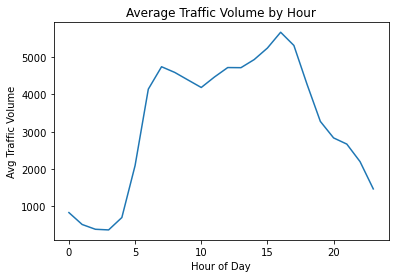

In [5]:

# Avg traffic by hour of day
hourly = df.groupby("hour")["traffic_volume"].mean()

plt.figure()
hourly.plot(kind='line', title="Average Traffic Volume by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Avg Traffic Volume")
plt.show()


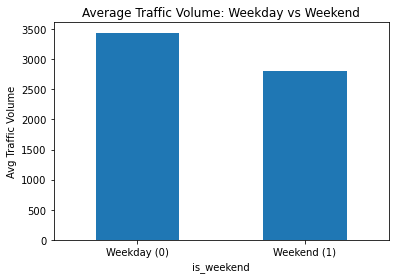

In [6]:

# Weekday vs Weekend
weekend_stats = df.groupby("is_weekend")["traffic_volume"].mean()
labels = ["Weekday (0)","Weekend (1)"]

plt.figure()
weekend_stats.plot(kind='bar', title="Average Traffic Volume: Weekday vs Weekend")
plt.xlabel("is_weekend")
plt.ylabel("Avg Traffic Volume")
plt.xticks([0,1], labels, rotation=0)
plt.show()


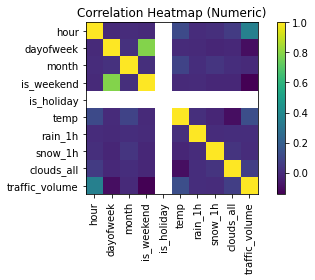

In [7]:

# Simple correlation heatmap (numeric cols)
num_cols = ["hour","dayofweek","month","is_weekend","is_holiday","temp","rain_1h","snow_1h","clouds_all","traffic_volume"]
corr = df[num_cols].corr()

plt.figure()
plt.imshow(corr, interpolation='nearest')
plt.title("Correlation Heatmap (Numeric)")
plt.colorbar()
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.tight_layout()
plt.show()



## 4) Modeling — Classification (Low/Medium/High)


In [8]:

# Features for classification
X_cls = df[["hour","dayofweek","month","is_weekend","is_holiday","temp","rain_1h","snow_1h","clouds_all","weather_main"]]
y_cls = df["congestion_level"]

# Identify categorical and numeric columns
cat_cols = ["weather_main"]
num_cols = [c for c in X_cls.columns if c not in cat_cols]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)

clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="weighted", zero_division=0)
cm = confusion_matrix(y_test, y_pred, labels=["Low","Medium","High"])

print(f"Accuracy: {acc:.3f}")
print(f"Precision: {prec:.3f} | Recall: {rec:.3f} | F1: {f1:.3f}")
print("Confusion Matrix (rows:true, cols:pred):\n", cm)


Accuracy: 0.860
Precision: 0.861 | Recall: 0.860 | F1: 0.860
Confusion Matrix (rows:true, cols:pred):
 [[2745  234   66]
 [ 162 2526  517]
 [  38  333 3020]]


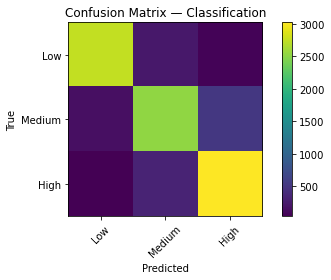

In [9]:

# Visualize confusion matrix
labels = ["Low","Medium","High"]
plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix — Classification")
plt.colorbar()
plt.xticks(range(len(labels)), labels, rotation=45)
plt.yticks(range(len(labels)), labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()



## 5) Modeling — Regression (Predict Numeric Traffic Volume)


In [10]:

X_reg = df[["hour","dayofweek","month","is_weekend","is_holiday","temp","rain_1h","snow_1h","clouds_all","weather_main"]]
y_reg = df["traffic_volume"]

reg = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(n_estimators=200, random_state=42))
])

Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

reg.fit(Xr_train, yr_train)
yr_pred = reg.predict(Xr_test)

mae = mean_absolute_error(yr_test, yr_pred)
rmse = mean_squared_error(yr_test, yr_pred, squared=False)
r2 = r2_score(yr_test, yr_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R^2: {r2:.3f}")


MAE: 408.57
RMSE: 701.08
R^2: 0.876



## 6) Save Models


In [11]:

model_dir = Path("/mnt/data/models")
model_dir.mkdir(parents=True, exist_ok=True)

cls_path = model_dir / "rf_congestion_classifier.joblib"
reg_path = model_dir / "rf_traffic_regressor.joblib"

joblib.dump(clf, cls_path)
joblib.dump(reg, reg_path)

print("Saved:", cls_path)
print("Saved:", reg_path)


Saved: \mnt\data\models\rf_congestion_classifier.joblib
Saved: \mnt\data\models\rf_traffic_regressor.joblib



## 7) Simple Prediction Helper




In [12]:

def predict_congestion_and_volume(
    hour:int,
    dayofweek:int,
    month:int,
    is_weekend:int,
    is_holiday:int,
    temp:float,
    rain_1h:float,
    snow_1h:float,
    clouds_all:float,
    weather_main:str="Clear",
    classifier_path="/mnt/data/models/rf_congestion_classifier.joblib",
    regressor_path="/mnt/data/models/rf_traffic_regressor.joblib"
):
    # Load trained models
    clf_loaded = joblib.load(classifier_path)
    reg_loaded = joblib.load(regressor_path)

    # Prepare input
    X = pd.DataFrame([{
        "hour": hour,
        "dayofweek": dayofweek,
        "month": month,
        "is_weekend": is_weekend,
        "is_holiday": is_holiday,
        "temp": temp,
        "rain_1h": rain_1h,
        "snow_1h": snow_1h,
        "clouds_all": clouds_all,
        "weather_main": weather_main
    }])

    # Predictions
    level = clf_loaded.predict(X)[0]
    vol = reg_loaded.predict(X)[0]

    return level, int(round(vol))


if __name__ == "__main__":
    print("=== Traffic Congestion Prediction ===")
    hour = int(input("Enter hour of day (0–23): "))
    dayofweek = int(input("Enter day of week (0=Mon … 6=Sun): "))
    month = int(input("Enter month (1–12): "))
    is_weekend = int(input("Is it weekend? (1=yes, 0=no): "))
    is_holiday = int(input("Is it holiday? (1=yes, 0=no): "))
    temp = float(input("Enter temperature (°C): "))
    rain_1h = float(input("Rainfall last 1h (mm): "))
    snow_1h = float(input("Snowfall last 1h (mm): "))
    clouds_all = float(input("Cloud cover (%) 0–100: "))
    weather_main = input("Main weather (Clear/Clouds/Rain/Snow/etc.): ")

    level, volume = predict_congestion_and_volume(
        hour, dayofweek, month, is_weekend, is_holiday,
        temp, rain_1h, snow_1h, clouds_all, weather_main
    )

    print(f"\nPredicted congestion level: {level}")
    print(f"Predicted traffic volume: {volume}")


=== Traffic Congestion Prediction ===
Enter hour of day (0–23): 16
Enter day of week (0=Mon … 6=Sun): 0
Enter month (1–12): 2
Is it weekend? (1=yes, 0=no): 0
Is it holiday? (1=yes, 0=no): 0
Enter temperature (°C): 21
Rainfall last 1h (mm): 0
Snowfall last 1h (mm): 0
Cloud cover (%) 0–100: 50
Main weather (Clear/Clouds/Rain/Snow/etc.): Claer

Predicted congestion level: Medium
Predicted traffic volume: 4639


In [13]:
import joblib
import pandas as pd
import time

def predict_congestion_and_volume(
    hour:int,
    dayofweek:int,
    month:int,
    is_weekend:int,
    is_holiday:int,
    temp:float,
    rain_1h:float,
    snow_1h:float,
    clouds_all:float,
    weather_main:str="Clear",
    classifier_path="/mnt/data/models/rf_congestion_classifier.joblib",
    regressor_path="/mnt/data/models/rf_traffic_regressor.joblib"
):
    clf_loaded = joblib.load(classifier_path)
    reg_loaded = joblib.load(regressor_path)

    X = pd.DataFrame([{
        "hour": hour,
        "dayofweek": dayofweek,
        "month": month,
        "is_weekend": is_weekend,
        "is_holiday": is_holiday,
        "temp": temp,
        "rain_1h": rain_1h,
        "snow_1h": snow_1h,
        "clouds_all": clouds_all,
        "weather_main": weather_main
    }])

    level = clf_loaded.predict(X)[0]
    vol = reg_loaded.predict(X)[0]

    return level, int(round(vol))


def traffic_light_controller(volume:int):
    """
    Adjusts red light timing based on predicted traffic volume.
    """
    if volume < 2500:   # Low traffic
        red_time = 30 # seconds
    elif 2500 < volume < 3500:
        red_time = 60
    else:              # High traffic
        red_time = 90   # 1.5 minutes

    print(f"\nPredicted Traffic Volume: {volume}")
    print(f"Red light ON for {red_time} seconds")

if __name__ == "__main__":
    # Example prediction input
    level, volume = predict_congestion_and_volume(
        hour=9, dayofweek=2, month=8, is_weekend=0, is_holiday=0,
        temp=29.5, rain_1h=0.0, snow_1h=0.0, clouds_all=20, weather_main="Clear"
    )

    print(f"Predicted congestion level: {level}")
    traffic_light_controller(volume)


Predicted congestion level: High

Predicted Traffic Volume: 3673
Red light ON for 90 seconds


In [14]:
import pickle


# Save the trained pipeline
with open("Traffic_Congestion_Prediction.pkl", "wb") as f:
    pickle.dump(clf, f)
